# DLP End-to-End Evaluation

This notebook runs the mock-agent test suite over the `dlp` module.
We evaluate the three surfaces (`OUTPUT`, `TOOL_ARGS`, `TOOL_RESULT`).

We test configurations of our optional features:
- `enable_luhn_validation`
- `enable_context_analysis`

This evaluation allows for better comprehension and interpretation of the impact of each step/feature in the scanning pipeline.

In [21]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Ensure the dlp package is in the path
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))

from runner import Evaluator
from dlp.config import DLPConfig
import itertools

## 1. Run the Evaluation Suite

In [22]:
corpus_path = "corpus.json"
evaluator = Evaluator(corpus_path)
print(f"Loaded {len(evaluator.cases)} test cases from corpus.")

# DEFINE CONFIGS HERE IN THE NOTEBOOK
features = [
    "enable_luhn_validation",
    "enable_context_analysis"
]

configs_to_run = {}

# Generate all combinations of True/False for the features
for combination in itertools.product([False, True], repeat=len(features)):
    config = DLPConfig.defaults()
    config_name_parts = []
    
    for feature_idx, feature_val in enumerate(combination):
        setattr(config, features[feature_idx], feature_val)
        if feature_val:
            # e.g., enable_luhn_validation -> LUHN
            config_name_parts.append(features[feature_idx].replace("enable_", "").upper())
            
    # Name the config based on enabled features, or NONE if all are false
    config_name = "+".join(config_name_parts) if config_name_parts else "NONE"
    if config_name == "LUHN_VALIDATION+CONTEXT_ANALYSIS":
        config_name = "ALL_FEATURES"
    
    configs_to_run[config_name] = config

print(f"Generated {len(configs_to_run)} configurations to run.")
print("Running evaluations... this may take a moment.")
results = evaluator.run_all(configs_to_run)
print(f"Completed {len(results)} evaluations.")

KeyError: 'category'

## 2. Load Results into Pandas

In [ ]:
df = pd.DataFrame([vars(r) for r in results])
# Show an overview of the results
df.head()

,case_id,category,surface,config_type,expected_action,actual_action,passed,latency_ms,violations,clean_text_or_payload,message
0,allow-benign-01,BENIGN,OUTPUT,NONE,ALLOW,ALLOW,True,0.048637,[],"Hello! I can help summarize your notes, draft ...",
1,allow-benign-02,BENIGN,OUTPUT,NONE,ALLOW,ALLOW,True,0.030518,[],Documentation note: OpenAI API keys are usuall...,
2,allow-benign-03,BENIGN,OUTPUT,NONE,ALLOW,REDACT,False,0.058174,[pii],This fake card number [REDACTED_pii_credit_car...,
3,allow-benign-04,BENIGN,TOOL_ARGS,NONE,ALLOW,ALLOW,True,0.041008,[],"{""action"": ""search"", ""query"": ""public Stripe A...",
4,allow-benign-05,BENIGN,TOOL_ARGS,NONE,ALLOW,ALLOW,True,0.036240,[],"{""action"": ""lint_regex"", ""pattern"": ""AKIA[0-9A...",


## 3. Top-Level Metrics & Accuracy

In [ ]:
total = len(df)
passed = df['passed'].sum()
accuracy = passed / total * 100

print(f"Overall Accuracy: {accuracy:.2f}%")
print(f"Passed: {passed}/{total}")

# Calculate accuracy and F1 score by configuration type
def calc_metrics(group):
    acc = group['passed'].mean()
    f1 = f1_score(group['expected_action'], group['actual_action'], average='macro')
    return pd.Series({'Accuracy': acc, 'F1_Score': f1})

metrics_by_config = df.groupby('config_type').apply(calc_metrics).sort_values(by='Accuracy', ascending=False)

print("\nTop 10 Configurations by Accuracy:")
display(metrics_by_config.head(10).style.format("{:.2%}"))

print("\nBottom 5 Configurations by Accuracy:")
display(metrics_by_config.tail(5).style.format("{:.2%}"))

# Display the crosstab for a selection of configurations (e.g., top 3, bottom 2, and NONE/ALL_FEATURES if available)
special_configs = ["NONE", "ALL_FEATURES", "STRUCTURED_SCAN"]
selection = list(metrics_by_config.head(3).index) + list(metrics_by_config.tail(2).index) + special_configs
selection = list(dict.fromkeys(selection)) # remove duplicates

selected_df = df[df['config_type'].isin(selection)]
print("\nPass/Fail breakdown for selected configurations:")
display(pd.crosstab(selected_df['config_type'], selected_df['passed'], margins=True, normalize='index').style.format("{:.2%}"))

Overall Accuracy: 59.11%
Passed: 227/384

Top 10 Configurations by Accuracy:


,Accuracy,F1_Score
config_type,,
ALL_FEATURES,59.38%,51.63%
CONTEXT_ANALYSIS,59.38%,51.63%
LUHN_VALIDATION,59.38%,51.87%
NONE,58.33%,51.15%



Bottom 5 Configurations by Accuracy:


,Accuracy,F1_Score
config_type,,
ALL_FEATURES,59.38%,51.63%
CONTEXT_ANALYSIS,59.38%,51.63%
LUHN_VALIDATION,59.38%,51.87%
NONE,58.33%,51.15%



Pass/Fail breakdown for selected configurations:


passed,False,True
config_type,,
ALL_FEATURES,40.62%,59.38%
CONTEXT_ANALYSIS,40.62%,59.38%
LUHN_VALIDATION,40.62%,59.38%
NONE,41.67%,58.33%
All,40.89%,59.11%


## 4. Analyze Failures
Let's look specifically at any test cases that failed. Ambiguous cases might fail in DEFAULT but pass in ALL_FEATURES if ContextAnalyzer catches them.

In [ ]:
failures = df[df['passed'] == False]
if failures.empty:
    print("All tests passed!")
else:
    print("Failed tests:")
    display(failures[['case_id', 'config_type', 'expected_action', 'actual_action']])

Failed tests:


,case_id,category,config_type,expected_action,actual_action
2,allow-benign-03,BENIGN,NONE,ALLOW,REDACT
17,allow-ambiguous-02,AMBIGUOUS,NONE,ALLOW,REDACT
26,redact-benign-03,BENIGN,NONE,REDACT,ALLOW
28,redact-benign-05,BENIGN,NONE,REDACT,ALLOW
41,redact-ambiguous-02,AMBIGUOUS,NONE,REDACT,ALLOW
...,...,...,...,...,...
373,block-malicious-06,MALICIOUS,ALL_FEATURES,BLOCK,ALLOW
376,block-ambiguous-01,AMBIGUOUS,ALL_FEATURES,BLOCK,ALLOW
378,block-ambiguous-03,AMBIGUOUS,ALL_FEATURES,BLOCK,REDACT
382,block-ambiguous-07,AMBIGUOUS,ALL_FEATURES,BLOCK,REDACT


## 5. Performance / Latency Analysis
NER and other features add latency. Let's visualize the impact.

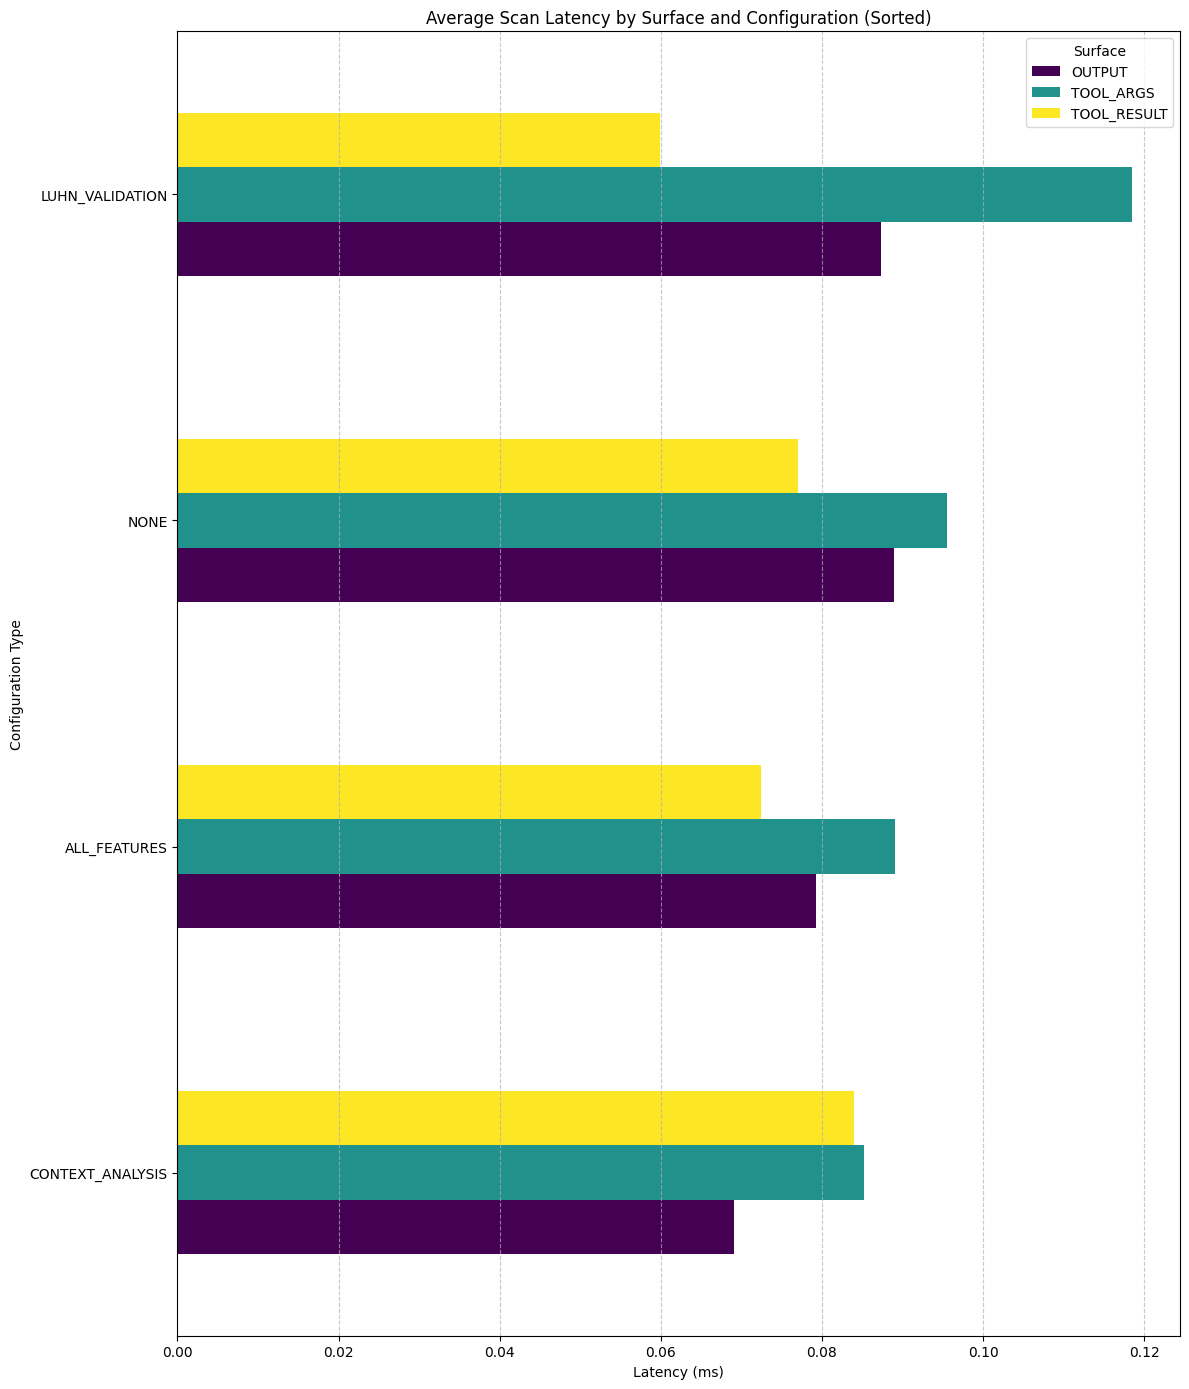

In [ ]:
latency_summary = df.groupby(['config_type', 'surface'])['latency_ms'].mean().unstack()

# Sort configs by average latency
latency_summary['AverageTotal'] = latency_summary.mean(axis=1)
latency_summary = latency_summary.sort_values('AverageTotal')
latency_summary = latency_summary.drop(columns=['AverageTotal'])

# Because 32 configurations are a lot, we use a horizontal bar chart and adjust the figure size
ax = latency_summary.plot(kind='barh', figsize=(12, 14), colormap='viridis')
plt.title('Average Scan Latency by Surface and Configuration (Sorted)')
plt.ylabel('Configuration Type')
plt.xlabel('Latency (ms)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Surface')
plt.tight_layout()
plt.show()

## 6. Confusion Matrix: Expected vs Actual Actions

In [ ]:
print("Confusion Matrix for NONE Config:")
none_df = df[df['config_type'] == 'NONE']
if not none_df.empty:
    display(pd.crosstab(none_df['expected_action'], none_df['actual_action'], margins=True))

print("\nConfusion Matrix for ALL_FEATURES Config:")
feature_df = df[df['config_type'] == 'ALL_FEATURES']
if not feature_df.empty:
    display(pd.crosstab(feature_df['expected_action'], feature_df['actual_action'], margins=True))
    
# Display confusion matrix for the most accurate configuration
best_config_name = metrics_by_config.index[0]
if best_config_name not in ['NONE', 'ALL_FEATURES']:
    print(f"\nConfusion Matrix for Most Accurate Config ({best_config_name}):")
    best_df = df[df['config_type'] == best_config_name]
    display(pd.crosstab(best_df['expected_action'], best_df['actual_action'], margins=True))

Confusion Matrix for NONE Config:


actual_action,ALLOW,BLOCK,REDACT,All
expected_action,,,,
ALLOW,22,0,2,24
BLOCK,6,14,4,24
ESCALATE,3,0,21,24
REDACT,4,0,20,24
All,35,14,47,96



Confusion Matrix for ALL_FEATURES Config:


actual_action,ALLOW,BLOCK,REDACT,All
expected_action,,,,
ALLOW,23,0,1,24
BLOCK,6,14,4,24
ESCALATE,15,0,9,24
REDACT,4,0,20,24
All,48,14,34,96


## 7. Comparative Feature Evaluation
We will evaluate the average accuracy and macro F1 score for configurations with and without each feature to quantify each feature's contribution.

,Feature,Acc_With,Acc_Without,Acc_Diff,F1_With,F1_Without,F1_Diff
0,LUHN_VALIDATION,59.38%,58.85%,+0.52%,0.5147,0.5110,+0.0037
1,CONTEXT_ANALYSIS,59.38%,58.85%,+0.52%,0.5163,0.5151,+0.0012


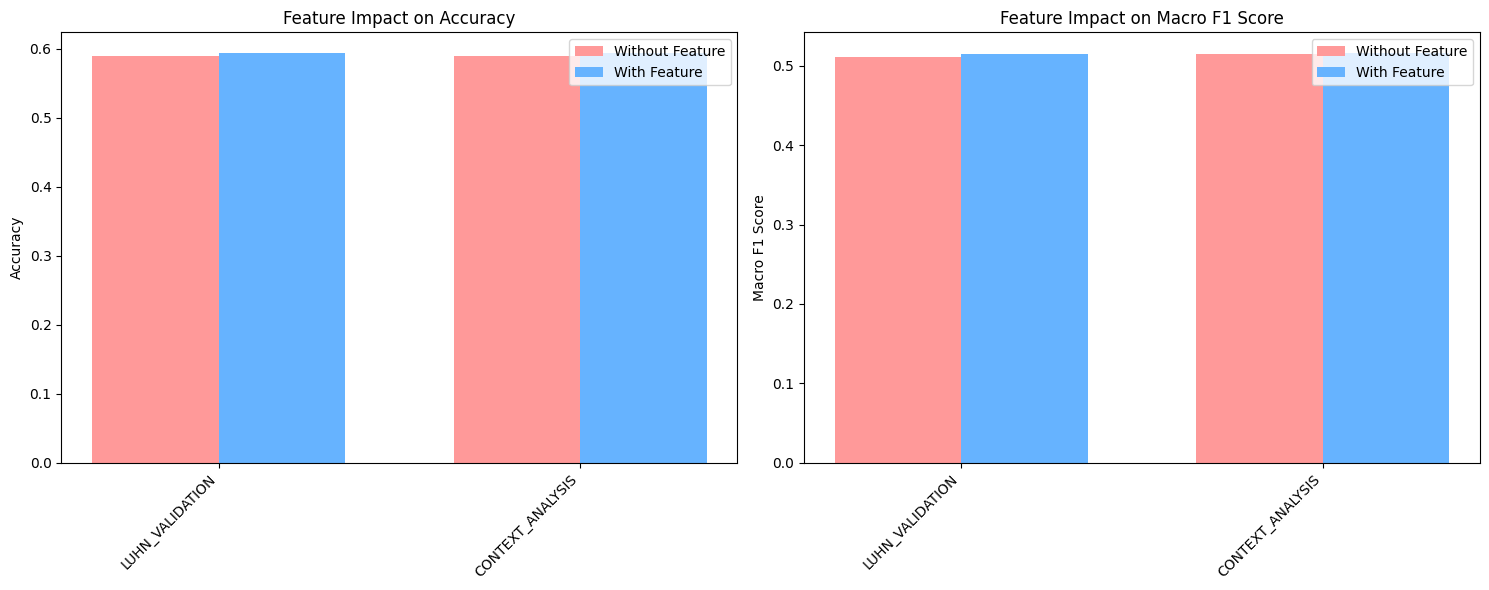

In [ ]:
import numpy as np

features_list = [
    ("LUHN_VALIDATION", "enable_luhn_validation"),
    ("CONTEXT_ANALYSIS", "enable_context_analysis")
]

feature_impact = []
for feat_name, _ in features_list:
    def has_feature(c_type, feat_name=feat_name):
        if c_type == "ALL_FEATURES":
            return True
        if c_type == "NONE":
            return False
        return feat_name in c_type.split('+')
    
    mask = df['config_type'].apply(has_feature)
    df_with = df[mask]
    df_without = df[~mask]
    
    acc_with = df_with['passed'].mean()
    acc_without = df_without['passed'].mean()
    
    f1_with = f1_score(df_with['expected_action'], df_with['actual_action'], average='macro') if len(df_with) > 0 else 0
    f1_without = f1_score(df_without['expected_action'], df_without['actual_action'], average='macro') if len(df_without) > 0 else 0
    
    feature_impact.append({
        'Feature': feat_name,
        'Acc_With': acc_with,
        'Acc_Without': acc_without,
        'Acc_Diff': acc_with - acc_without,
        'F1_With': f1_with,
        'F1_Without': f1_without,
        'F1_Diff': f1_with - f1_without
    })

impact_df = pd.DataFrame(feature_impact)
display(impact_df.style.format({
    'Acc_With': "{:.2%}", 'Acc_Without': "{:.2%}", 'Acc_Diff': "{:+.2%}",
    'F1_With': "{:.4f}", 'F1_Without': "{:.4f}", 'F1_Diff': "{:+.4f}"
}).background_gradient(subset=['Acc_Diff', 'F1_Diff'], cmap='hot'))

# Plotting the comparative evaluation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(impact_df))
width = 0.35

# Accuracy chart
axes[0].bar(x - width/2, impact_df['Acc_Without'], width, label='Without Feature', color='#ff9999')
axes[0].bar(x + width/2, impact_df['Acc_With'], width, label='With Feature', color='#66b3ff')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Feature Impact on Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(impact_df['Feature'], rotation=45, ha='right')
axes[0].legend()

# F1 Score chart
axes[1].bar(x - width/2, impact_df['F1_Without'], width, label='Without Feature', color='#ff9999')
axes[1].bar(x + width/2, impact_df['F1_With'], width, label='With Feature', color='#66b3ff')
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_title('Feature Impact on Macro F1 Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(impact_df['Feature'], rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Full Config Evaluation

### FULL_FEATURES Config: Failed Case Review
This section shows only test cases where the full-features configuration fails (expected action != actual action).

In [ ]:
import json

full_features_df = df[df['config_type'] == 'ALL_FEATURES'].copy()

content_df = pd.DataFrame([
    {
        'case_id': case.id,
        'content': json.dumps(case.input_payload, ensure_ascii=False) if not isinstance(case.input_payload, str) else case.input_payload,
    }
    for case in evaluator.cases
])

full_features_review_df = (
    content_df
    .merge(
        full_features_df[['case_id', 'surface', 'expected_action', 'actual_action', 'passed']],
        on='case_id',
        how='left',
    )
    .loc[:, ['case_id', 'surface', 'content', 'expected_action', 'actual_action', 'passed']]
 )

wrong_full_features_df = full_features_review_df[full_features_review_df['expected_action'] != full_features_review_df['actual_action']].copy()
print(f"Full-features config got {len(wrong_full_features_df)} of {len(full_features_review_df)} cases wrong.")

if wrong_full_features_df.empty:
    print("No failing cases for ALL_FEATURES.")
else:
    display(wrong_full_features_df.style.format({'passed': lambda value: 'PASS' if value else 'FAIL'}))

Full-features config got 39 of 96 cases wrong.


,case_id,category,surface,content,expected_action,actual_action,passed
17,allow-ambiguous-02,AMBIGUOUS,OUTPUT,Here is an example email address for a tutorial: example.user@example.com,ALLOW,REDACT,FAIL
26,redact-benign-03,BENIGN,OUTPUT,"Employee emergency contact on file: Maria Lopez, +34 600 123 456.",REDACT,ALLOW,FAIL
28,redact-benign-05,BENIGN,TOOL_ARGS,"{""action"": ""send_sms"", ""message"": ""Your technician is on the way."", ""phone"": ""415-555-0177""}",REDACT,ALLOW,FAIL
41,redact-ambiguous-02,AMBIGUOUS,OUTPUT,Applicant phone on file: 555-010-7733.,REDACT,ALLOW,FAIL
44,redact-ambiguous-05,AMBIGUOUS,TOOL_RESULT,"{""transcript"": ""Call me back at 212-555-0191 after 6 pm.""}",REDACT,ALLOW,FAIL
48,escalate-benign-01,BENIGN,OUTPUT,"Quarterly customer export preview: amy@shop.example, ben@shop.example, cara@shop.example, dan@shop.example, ella@shop.example. Review before release.",ESCALATE,REDACT,FAIL
49,escalate-benign-02,BENIGN,OUTPUT,"Recruiting sheet summary: noa@talent.example 202-555-0131, ibrahim@talent.example 202-555-0132, lina@talent.example 202-555-0133.",ESCALATE,ALLOW,FAIL
50,escalate-benign-03,BENIGN,OUTPUT,"Clinic intake sample includes patient contacts: maya@clinic.example, omar@clinic.example, sara@clinic.example, with call-back numbers 646-555-0111 and 646-555-0112.",ESCALATE,ALLOW,FAIL
51,escalate-benign-04,BENIGN,TOOL_ARGS,"{""action"": ""upload_csv"", ""destination"": ""analytics_vendor"", ""rows"": [""jules@retail.example"", ""farah@retail.example"", ""mina@retail.example"", ""sofia@retail.example""]}",ESCALATE,ALLOW,FAIL
52,escalate-benign-05,BENIGN,TOOL_ARGS,"{""action"": ""sync_contacts"", ""payload"": ""helen@finance.example, rami@finance.example, karim@finance.example, 415-555-0101, 415-555-0102""}",ESCALATE,ALLOW,FAIL
